In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sample/acme_corp.csv")
FEATURES = ["revenue", "expenses", "assets", "liabilities",
            "equity", "inventory", "net_profit"]
TARGET = "operating_cash_flow"

X = df[FEATURES].shift(1).dropna()
y = df[TARGET].iloc[1:]
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 8 | Test size: 3


In [8]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=5, random_state=42, verbosity=0),
    "Linear Regression": LinearRegression(),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "R²": round(r2_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,R²
0,Random Forest,2880.00,-1.9645
1,XGBoost,2333.34,-0.6579
2,Linear Regression,1691.61,-0.3226


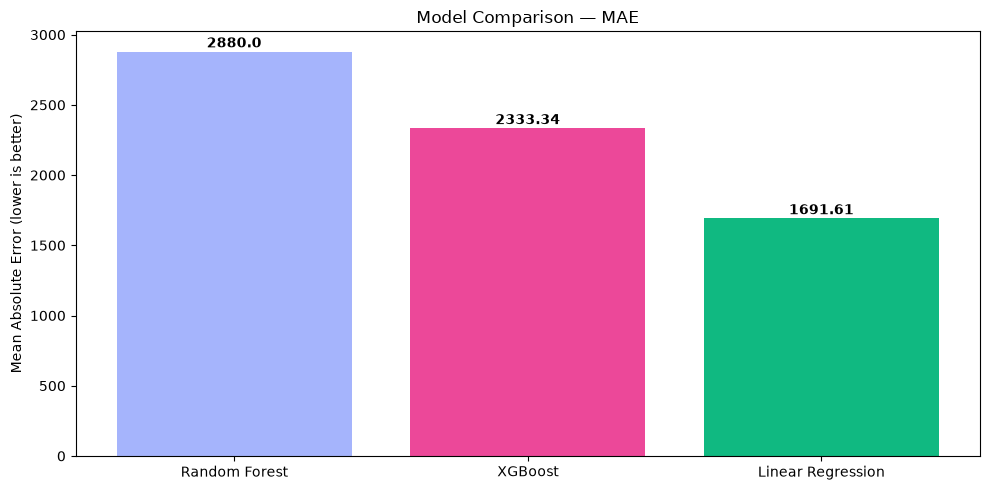

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#a5b4fc", "#ec4899", "#10b981"]
bars = ax.bar(results_df["Model"], results_df["MAE"], color=colors)

for bar, mae in zip(bars, results_df["MAE"]):
    ax.text(bar.get_x() + bar.get_width()/2, mae + 30, f"{mae}",
            ha="center", color="black", fontweight="bold")

ax.set_ylabel("Mean Absolute Error (lower is better)")
ax.set_title("Model Comparison — MAE")
plt.tight_layout()
plt.show()

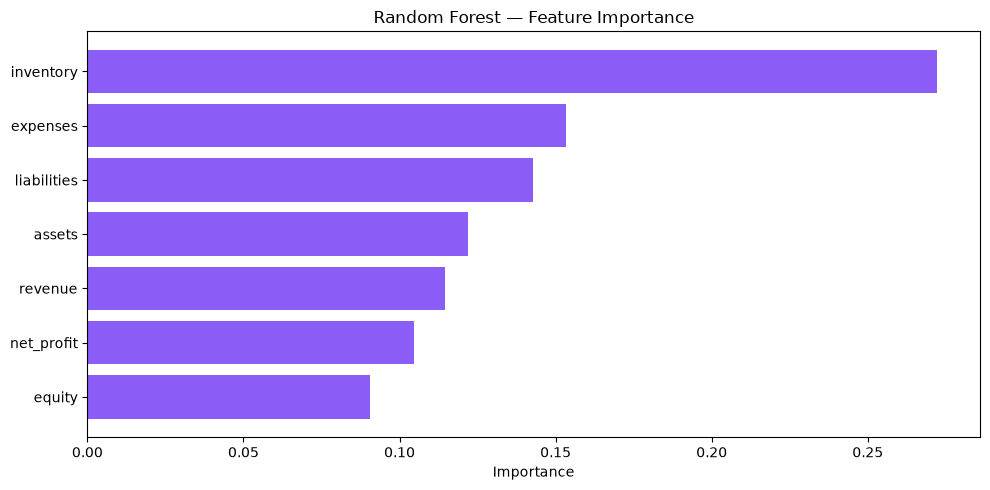

In [10]:
rf = models["Random Forest"]
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance["Feature"], importance["Importance"], color="#8b5cf6")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()